# Subject Co-evolution and Distributional Change

This notebook contains the exploratory analysis of subject shares and the distributional and co-evolution analysis.

The concise workflow is:

1. summarize the historical pure, applied, and all-math compositions;
2. measure diversity and concentration using Shannon entropy;
3. identify periods of large distributional change using Jensen–Shannon divergence;
4. examine which subjects change together between consecutive five-year periods;
5. identify subjects that evolve proportionally using log-ratio variation;
6. compare relative share co-movement with absolute count-growth co-movement.

The main analysis uses original observed `subject_code` values from **1960–2024**.

Five-year **pooled distributions** are used to reduce annual noise. This notebook does not use rolling five-year slopes or PCA.

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

## 0. Load and prepare the data

In [2]:
DATA_PATH = Path(
    "../../data/processed/version2_new_dataset_fitted.csv"
)

nodes = pd.read_csv(DATA_PATH, low_memory=False)

# Keep original observed subject classifications only.
nodes = nodes[
    nodes["subject_code"].notna()
    & nodes["year"].notna()
].copy()

if "predicted_subject_code" in nodes.columns:
    nodes = nodes[
        nodes["predicted_subject_code"].isna()
    ].copy()

nodes["subject_code"] = pd.to_numeric(
    nodes["subject_code"],
    errors="coerce",
)
nodes["year"] = pd.to_numeric(
    nodes["year"],
    errors="coerce",
)

nodes = nodes.dropna(
    subset=["subject_code", "year"]
)

nodes["subject_code"] = nodes["subject_code"].astype(int)
nodes["year"] = nodes["year"].astype(int)

YEAR_START = 1960
YEAR_END = 2024
YEARS = np.arange(YEAR_START, YEAR_END + 1)


def most_common_nonmissing(series):
    values = series.dropna().astype(str).str.strip()
    values = values[values.ne("")]

    if values.empty:
        return ""

    return values.value_counts().index[0]


if "subject_name" in nodes.columns:
    subject_name_map = (
        nodes.groupby("subject_code")["subject_name"]
        .apply(most_common_nonmissing)
        .to_dict()
    )
else:
    subject_name_map = {}


def subject_label(code):
    code = int(code)
    name = subject_name_map.get(code, "")
    return f"{code}: {name}" if name else str(code)


print("Original-label records:", f"{len(nodes):,}")
print(
    "Observed subject codes:",
    nodes["subject_code"].nunique()
)

Original-label records: 167,749
Observed subject codes: 63


In [3]:
def build_basket(data, basket):
    if basket == "Pure":
        mask = data["subject_code"].lt(61)
    elif basket == "Applied":
        mask = data["subject_code"].gt(61)
    elif basket == "All":
        mask = data["subject_code"].notna()
    else:
        raise ValueError(
            "basket must be 'Pure', 'Applied', or 'All'."
        )

    basket_nodes = data[
        mask
        & data["year"].between(YEAR_START, YEAR_END)
    ].copy()

    subject_codes = np.sort(
        basket_nodes["subject_code"].unique()
    )

    counts = (
        pd.crosstab(
            basket_nodes["subject_code"],
            basket_nodes["year"],
        )
        .reindex(
            index=subject_codes,
            columns=YEARS,
            fill_value=0,
        )
        .astype(float)
    )

    totals = counts.sum(axis=0)
    shares = (
        counts.div(
            totals.replace(0, np.nan),
            axis=1,
        )
        * 100
    )

    return {
        "nodes": basket_nodes,
        "counts": counts,
        "shares": shares,
        "totals": totals,
    }


baskets = {
    "Pure": build_basket(nodes, "Pure"),
    "Applied": build_basket(nodes, "Applied"),
    "All mathematics": build_basket(nodes, "All"),
}

basket_overview = pd.DataFrame(
    {
        name: {
            "number_of_subjects": basket["counts"].shape[0],
            "number_of_years": basket["counts"].shape[1],
            "records_1960_2024": int(basket["counts"].to_numpy().sum()),
        }
        for name, basket in baskets.items()
    }
).T

display(basket_overview)

,number_of_subjects,number_of_years,records_1960_2024
Pure,44,65,60894
Applied,19,65,100296
All mathematics,63,65,161190


## 1. Historical composition overview

The early MGP record is much smaller than the post-1960 record. Annual percentages in sparse years can therefore be unstable. The detailed analysis below begins in 1960.

For the composition plots, the eight subjects with the largest mean share during 2000–2024 are shown separately. The remaining subjects are combined as **Other**. A centered five-year moving average is used only to make the visualization easier to read.

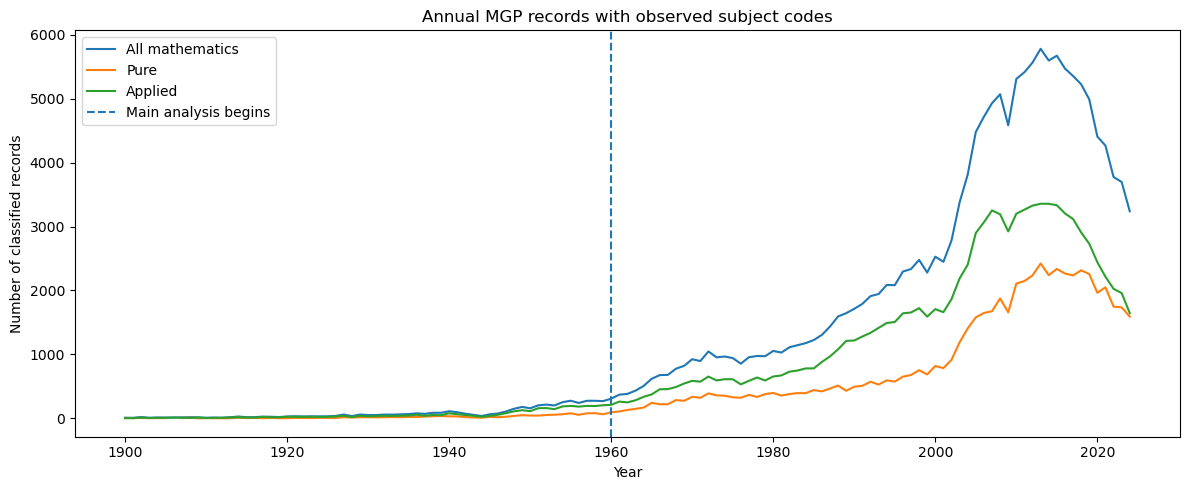

In [4]:
overview_start = 1900
overview_years = np.arange(overview_start, YEAR_END + 1)

overview_nodes = nodes[
    nodes["year"].between(overview_start, YEAR_END)
].copy()

annual_records = pd.DataFrame(
    {
        "All mathematics": (
            overview_nodes.groupby("year").size()
        ),
        "Pure": (
            overview_nodes[
                overview_nodes["subject_code"].lt(61)
            ]
            .groupby("year")
            .size()
        ),
        "Applied": (
            overview_nodes[
                overview_nodes["subject_code"].gt(61)
            ]
            .groupby("year")
            .size()
        ),
    }
).reindex(overview_years, fill_value=0)

plt.figure(figsize=(12, 5))

for column in annual_records.columns:
    plt.plot(
        annual_records.index,
        annual_records[column],
        label=column,
    )

plt.axvline(
    YEAR_START,
    linestyle="--",
    linewidth=1.5,
    label="Main analysis begins",
)
plt.xlabel("Year")
plt.ylabel("Number of classified records")
plt.title("Annual MGP records with observed subject codes")
plt.legend()
plt.tight_layout()
plt.show()

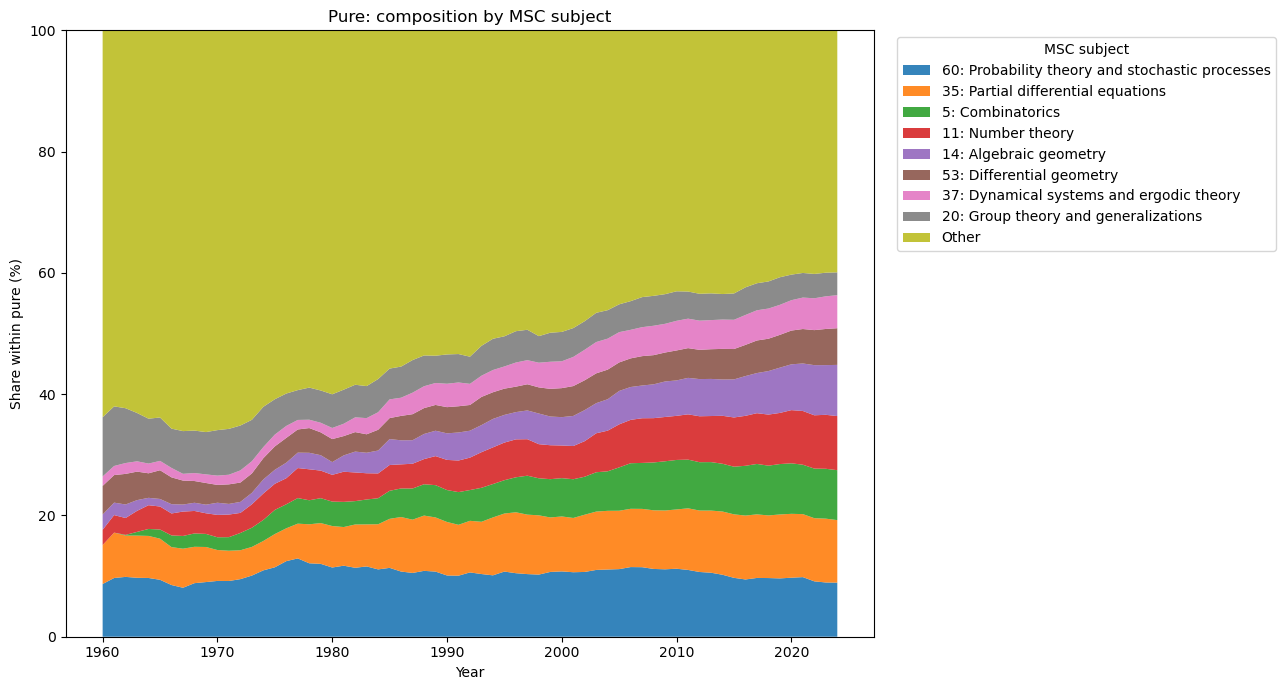

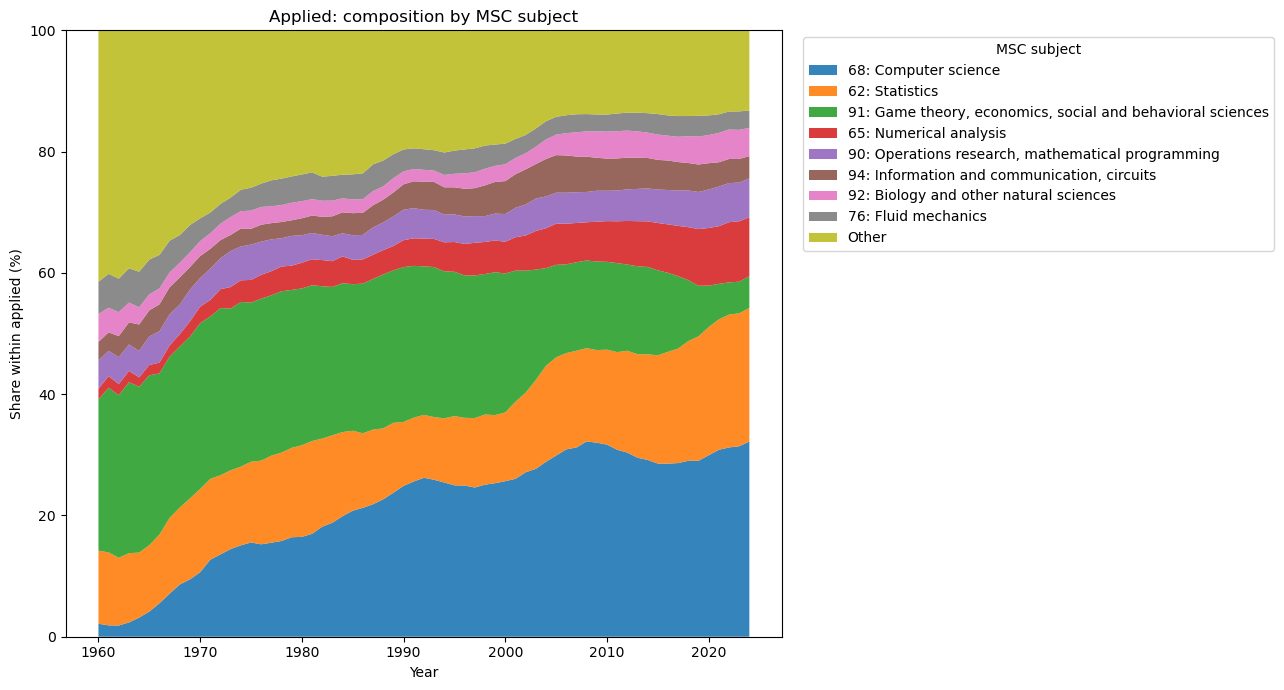

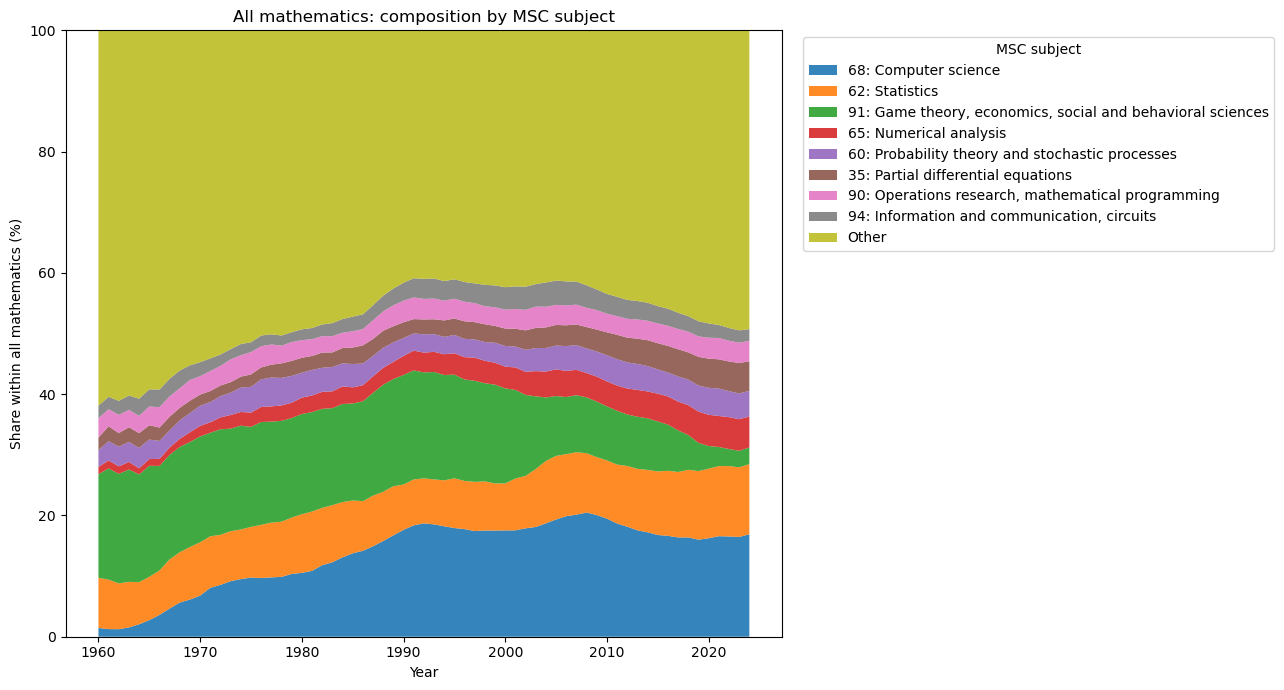

In [5]:
def plot_top_subject_area(
    basket_name,
    basket,
    top_n=8,
    ranking_start=2000,
    smoothing_window=5,
):
    shares = basket["shares"]

    top_subjects = (
        shares.loc[:, ranking_start:YEAR_END]
        .mean(axis=1)
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    area_data = shares.loc[top_subjects].T.copy()
    area_data["Other"] = (
        100 - area_data.sum(axis=1)
    ).clip(lower=0)

    area_data = (
        area_data
        .rolling(
            smoothing_window,
            center=True,
            min_periods=1,
        )
        .mean()
    )

    labels = [
        "Other"
        if column == "Other"
        else subject_label(column)
        for column in area_data.columns
    ]

    plt.figure(figsize=(13, 7))
    plt.stackplot(
        area_data.index,
        *[
            area_data[column].to_numpy()
            for column in area_data.columns
        ],
        labels=labels,
        alpha=0.9,
    )
    plt.xlabel("Year")
    plt.ylabel(f"Share within {basket_name.lower()} (%)")
    plt.title(
        f"{basket_name}: composition by MSC subject"
    )
    plt.ylim(0, 100)
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="MSC subject",
    )
    plt.tight_layout()
    plt.show()


for basket_name, basket in baskets.items():
    plot_top_subject_area(
        basket_name=basket_name,
        basket=basket,
    )

## 2. Diversity and concentration

Let $p_{j,t}$ be subject $j$'s proportion of the relevant distribution in year $t$.

The Shannon entropy is

$$
H_t=-\sum_j p_{j,t}\log p_{j,t}.
$$

The effective number of subjects is

$$
N_{\mathrm{eff},t}=e^{H_t}.
$$

The normalized entropy is

$$
H_t^{\mathrm{norm}}
=
\frac{H_t}{\log K},
$$

where $K$ is the number of subjects in the distribution. It lies between 0 and 1 and makes the pure, applied, and all-math distributions easier to compare despite their different numbers of subjects.

The Herfindahl index is

$$
\mathrm{HHI}_t=\sum_j p_{j,t}^2.
$$

Higher entropy indicates greater diversity, whereas higher HHI indicates greater concentration.

The all-math entropy reflects both:

- diversity within the pure and applied baskets;
- the changing balance between the pure and applied baskets.

In [6]:
def diversity_summary(share_matrix):
    proportions = (
        share_matrix
        .div(100)
        .fillna(0)
    )

    positive = proportions.where(proportions > 0)

    entropy = -(
        positive * np.log(positive)
    ).sum(axis=0)

    number_of_subjects = share_matrix.shape[0]

    normalized_entropy = (
        entropy / np.log(number_of_subjects)
    )

    effective_number = np.exp(entropy)
    hhi = (proportions ** 2).sum(axis=0)

    return pd.DataFrame(
        {
            "entropy": entropy,
            "normalized_entropy": normalized_entropy,
            "effective_number": effective_number,
            "HHI": hhi,
        }
    )


diversity = {
    name: diversity_summary(basket["shares"])
    for name, basket in baskets.items()
}

latest_diversity = pd.DataFrame(
    {
        name: table.loc[YEAR_END]
        for name, table in diversity.items()
    }
).T

display(latest_diversity.round(4))

,entropy,normalized_entropy,effective_number,HHI
Pure,3.2104,0.8484,24.7896,0.0541
Applied,2.1421,0.7275,8.5173,0.1790
All mathematics,3.3604,0.8111,28.7996,0.0593


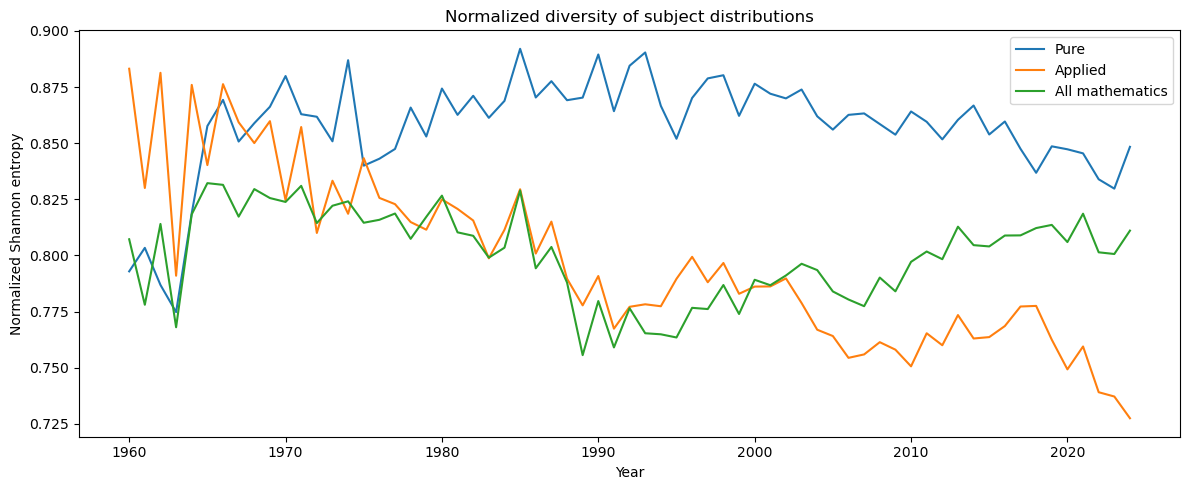

In [7]:
plt.figure(figsize=(12, 5))

for basket_name, table in diversity.items():
    plt.plot(
        table.index,
        table["normalized_entropy"],
        label=basket_name,
    )

plt.xlabel("Year")
plt.ylabel("Normalized Shannon entropy")
plt.title("Normalized diversity of subject distributions")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
pure_probability = (
    baskets["Pure"]["totals"]
    / baskets["All mathematics"]["totals"]
)

applied_probability = 1 - pure_probability

pure_entropy = diversity["Pure"]["entropy"]
applied_entropy = diversity["Applied"]["entropy"]

basket_entropy = -(
    pure_probability * np.log(pure_probability)
    + applied_probability * np.log(applied_probability)
)

within_pure_component = (
    pure_probability * pure_entropy
)

within_applied_component = (
    applied_probability * applied_entropy
)

entropy_decomposition = pd.DataFrame({
    "pure_applied_split": basket_entropy,
    "within_pure": within_pure_component,
    "within_applied": within_applied_component,
})

entropy_decomposition["reconstructed_all_entropy"] = (
    entropy_decomposition.sum(axis=1)
)

entropy_decomposition[
    "reported_all_entropy"
] = diversity["All mathematics"]["entropy"]

display(entropy_decomposition.tail())

,pure_applied_split,within_pure,within_applied,reconstructed_all_entropy,reported_all_entropy
year,,,,,
2020,0.687251,1.429226,1.222772,3.339249,3.339249
2021,0.692399,1.537825,1.161363,3.391587,3.391587
2022,0.690432,1.461636,1.168267,3.320335,3.320335
2023,0.691310,1.474841,1.151076,3.317226,3.317226
2024,0.693008,1.578442,1.088911,3.360361,3.360361


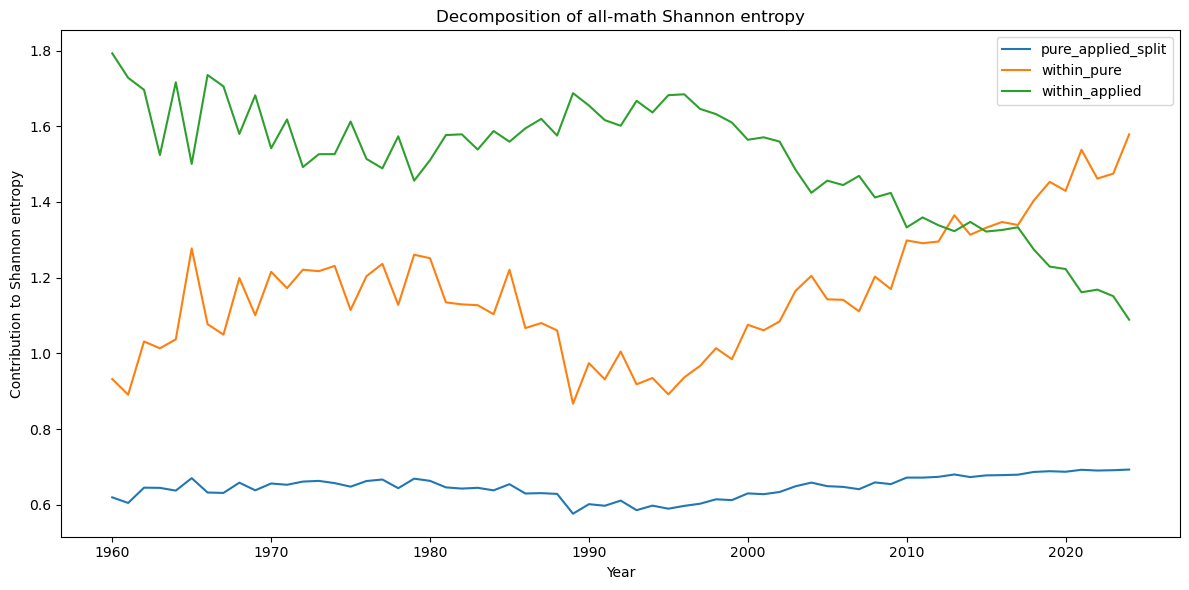

In [12]:
entropy_decomposition[
    [
        "pure_applied_split",
        "within_pure",
        "within_applied",
    ]
].plot(
    figsize=(12, 6),
    title="Decomposition of all-math Shannon entropy"
)

plt.xlabel("Year")
plt.ylabel("Contribution to Shannon entropy")
plt.tight_layout()
plt.show()

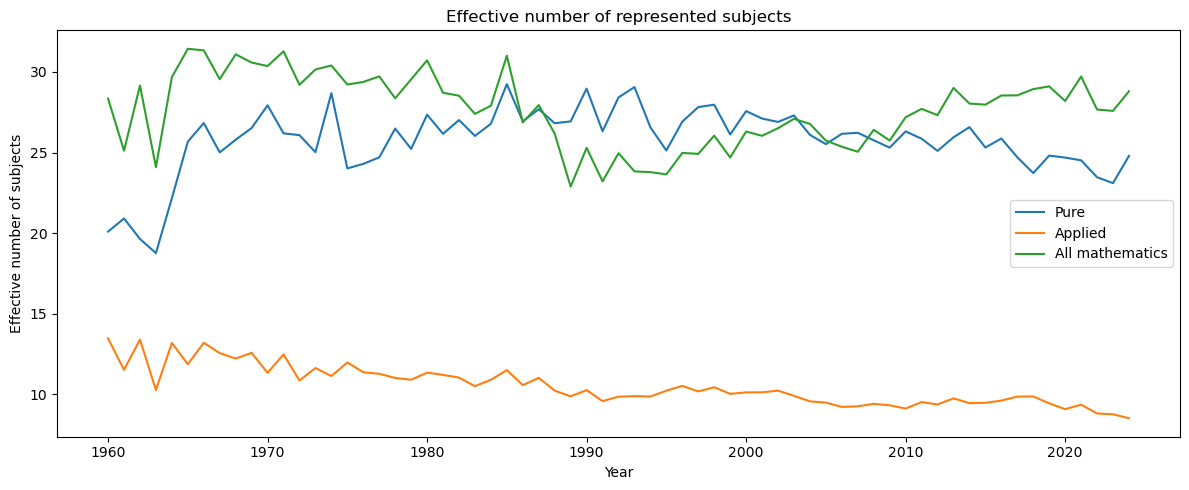

In [13]:
plt.figure(figsize=(12, 5))

for basket_name, table in diversity.items():
    plt.plot(
        table.index,
        table["effective_number"],
        label=basket_name,
    )

plt.xlabel("Year")
plt.ylabel("Effective number of subjects")
plt.title("Effective number of represented subjects")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Distributional change between historical periods

For two subject distributions $p$ and $q$, the Jensen–Shannon divergence is

$$
\operatorname{JSD}(p,q)
=
\frac{1}{2}D_{\mathrm{KL}}(p\|m)
+
\frac{1}{2}D_{\mathrm{KL}}(q\|m),
\qquad
m=\frac{p+q}{2}.
$$

Using logarithm base 2, JSD lies between 0 and 1:

- 0 means that the two distributions are identical;
- larger values indicate greater compositional change.

Counts are pooled within five-year periods to reduce annual noise.

In [14]:
def normalize_probability(vector):
    vector = np.asarray(vector, dtype=float)
    return vector / vector.sum()


def kl_divergence(p, q, epsilon=1e-12):
    p = normalize_probability(p)
    q = normalize_probability(q)
    q = np.clip(q, epsilon, None)

    return np.sum(
        np.where(
            p > 0,
            p * np.log2(p / q),
            0,
        )
    )


def js_divergence(p, q):
    p = normalize_probability(p)
    q = normalize_probability(q)
    midpoint = 0.5 * (p + q)

    return (
        0.5 * kl_divergence(p, midpoint)
        + 0.5 * kl_divergence(q, midpoint)
    )


def aggregate_period_counts(count_matrix, width=5):
    years = count_matrix.columns.to_numpy(dtype=int)

    period_counts = {}

    for start in range(
        int(years.min()),
        int(years.max()) + 1,
        width,
    ):
        end = min(
            start + width - 1,
            int(years.max()),
        )

        selected_years = [
            year
            for year in years
            if start <= year <= end
        ]

        pooled = count_matrix[selected_years].sum(axis=1)
        period_counts[f"{start}-{end}"] = pooled

    return pd.DataFrame(period_counts)


def period_distributions(count_matrix, width=5):
    pooled_counts = aggregate_period_counts(
        count_matrix,
        width=width,
    )

    return pooled_counts.div(
        pooled_counts.sum(axis=0),
        axis=1,
    )


def consecutive_jsd(distributions):
    labels = list(distributions.columns)
    records = []

    for earlier, later in zip(labels[:-1], labels[1:]):
        records.append(
            {
                "from_period": earlier,
                "to_period": later,
                "JSD": js_divergence(
                    distributions[earlier],
                    distributions[later],
                ),
            }
        )

    return pd.DataFrame(records)


five_year_distributions = {
    name: period_distributions(
        basket["counts"],
        width=5,
    )
    for name, basket in baskets.items()
}

consecutive_jsd_tables = {
    name: consecutive_jsd(distributions)
    for name, distributions
    in five_year_distributions.items()
}

largest_changes = pd.concat(
    [
        table.nlargest(5, "JSD").assign(
            distribution=name
        )
        for name, table
        in consecutive_jsd_tables.items()
    ],
    ignore_index=True,
)

display(
    largest_changes[
        [
            "distribution",
            "from_period",
            "to_period",
            "JSD",
        ]
    ].round(4)
)

/var/folders/yp/d9rnnh0j12z5z6ps21r77d4r0000gn/T/ipykernel_2017/1078254217.py:14: RuntimeWarning: divide by zero encountered in log2
  p * np.log2(p / q),
/var/folders/yp/d9rnnh0j12z5z6ps21r77d4r0000gn/T/ipykernel_2017/1078254217.py:14: RuntimeWarning: invalid value encountered in multiply
  p * np.log2(p / q),


,distribution,from_period,to_period,JSD
0,Pure,1960-1964,1965-1969,0.0299
1,Pure,1965-1969,1970-1974,0.0185
2,Pure,1970-1974,1975-1979,0.0181
3,Pure,1980-1984,1985-1989,0.0111
4,Pure,1975-1979,1980-1984,0.0092
5,Applied,1960-1964,1965-1969,0.0214
6,Applied,1965-1969,1970-1974,0.0147
7,Applied,2015-2019,2020-2024,0.0128
8,Applied,2000-2004,2005-2009,0.0074
9,Applied,1970-1974,1975-1979,0.0057


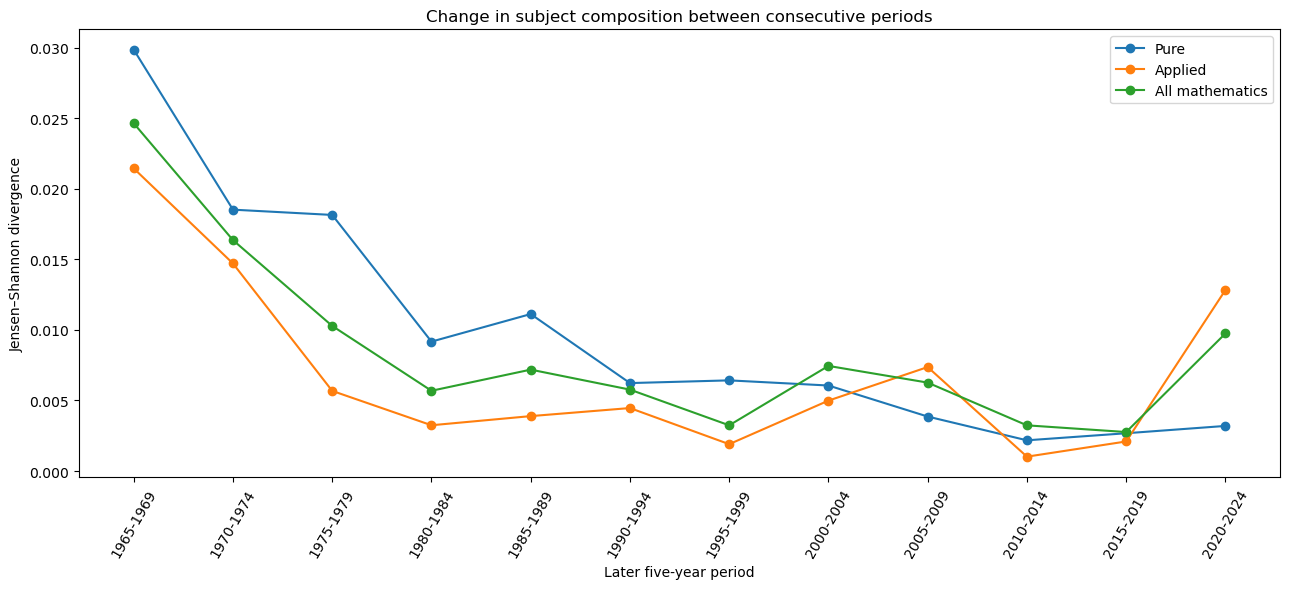

In [15]:
plt.figure(figsize=(13, 6))

for basket_name, table in consecutive_jsd_tables.items():
    plt.plot(
        table["to_period"],
        table["JSD"],
        marker="o",
        label=basket_name,
    )

plt.xticks(rotation=60)
plt.xlabel("Later five-year period")
plt.ylabel("Jensen–Shannon divergence")
plt.title(
    "Change in subject composition between consecutive periods"
)
plt.legend()
plt.tight_layout()
plt.show()

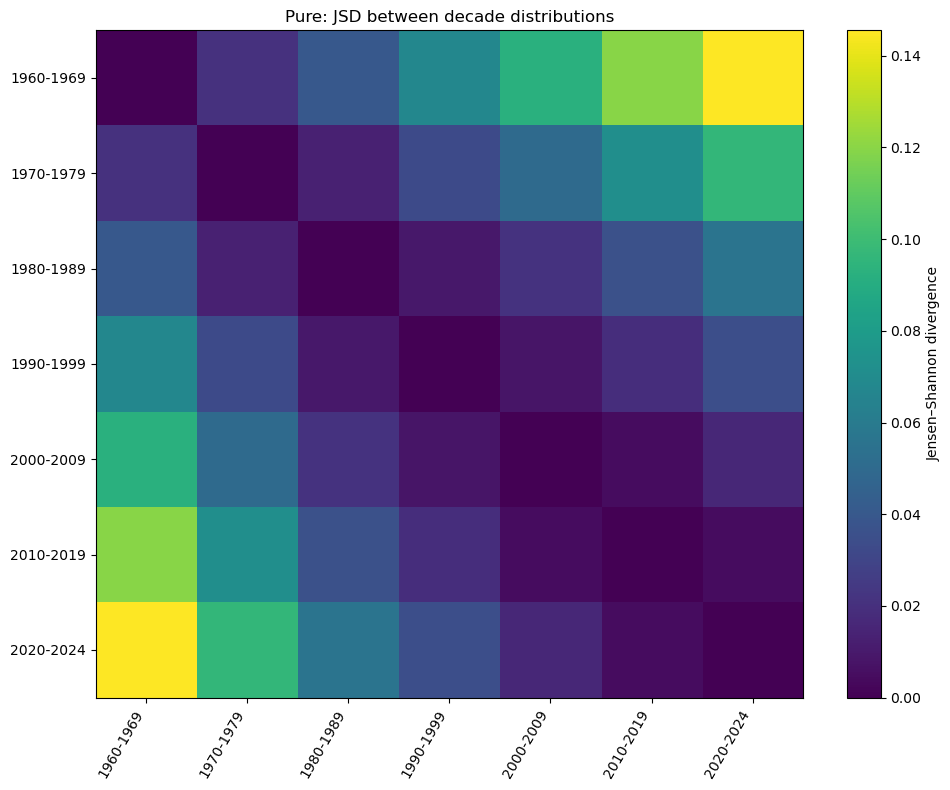

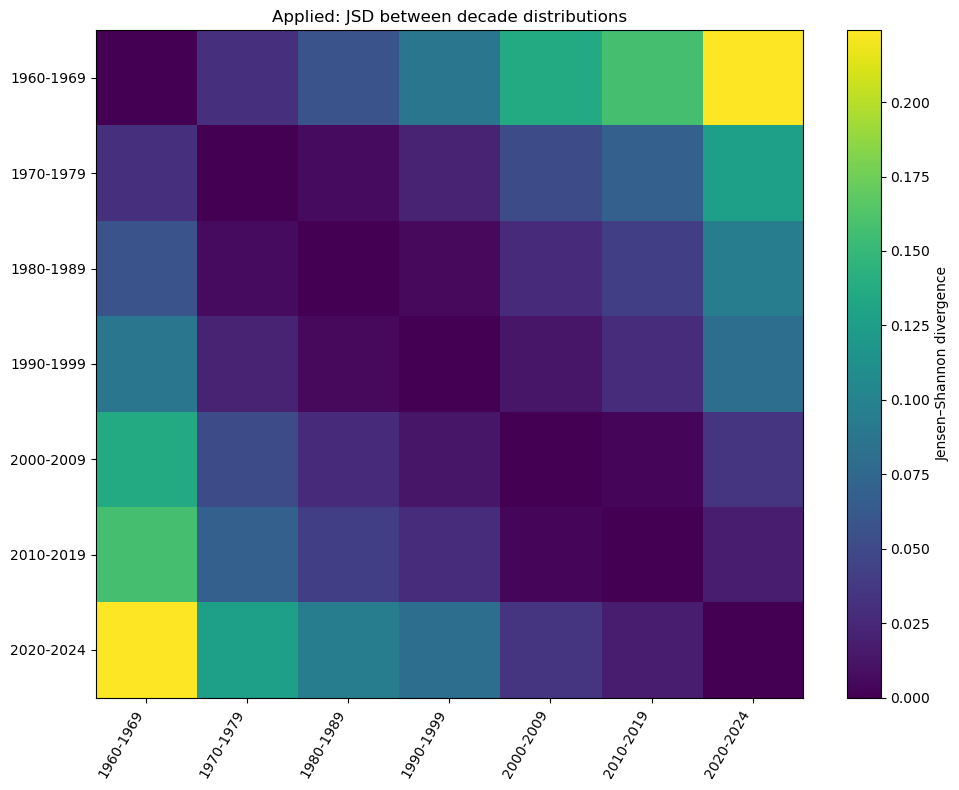

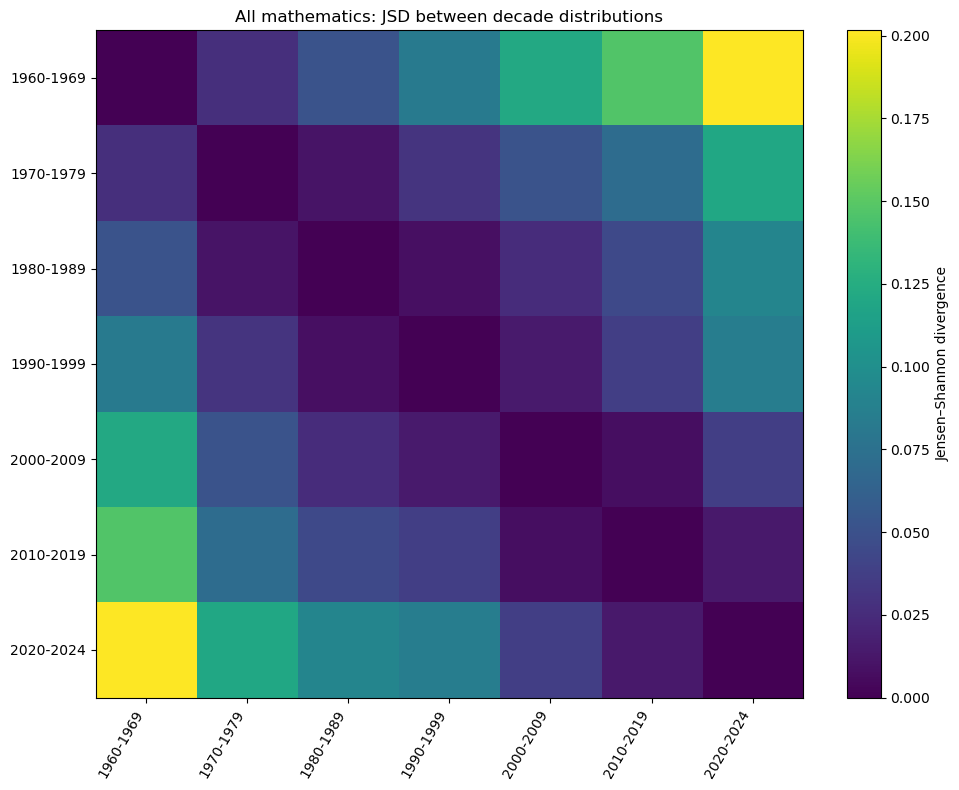

In [16]:
def pairwise_jsd_matrix(distributions):
    labels = list(distributions.columns)

    matrix = pd.DataFrame(
        np.zeros((len(labels), len(labels))),
        index=labels,
        columns=labels,
    )

    for left, right in combinations(labels, 2):
        value = js_divergence(
            distributions[left],
            distributions[right],
        )
        matrix.loc[left, right] = value
        matrix.loc[right, left] = value

    return matrix


def plot_square_heatmap(
    matrix,
    title,
    colorbar_label,
):
    plt.figure(figsize=(10, 8))
    image = plt.imshow(
        matrix.to_numpy(dtype=float),
        aspect="auto",
    )
    plt.colorbar(
        image,
        label=colorbar_label,
    )
    plt.xticks(
        np.arange(matrix.shape[1]),
        matrix.columns,
        rotation=60,
        ha="right",
    )
    plt.yticks(
        np.arange(matrix.shape[0]),
        matrix.index,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


for basket_name, basket in baskets.items():
    decade_distributions = period_distributions(
        basket["counts"],
        width=10,
    )

    plot_square_heatmap(
        pairwise_jsd_matrix(decade_distributions),
        title=(
            f"{basket_name}: "
            "JSD between decade distributions"
        ),
        colorbar_label="Jensen–Shannon divergence",
    )

## 4. Co-movement of subject-share changes

Instead of fitting rolling slopes, this section compares the change in each subject's share between consecutive five-year pooled periods.

For subject $j$ and consecutive periods $r-1$ and $r$,

$$
\Delta p_{j,r}
=
p_{j,r}-p_{j,r-1}.
$$

The correlation between two change series asks whether the subjects tend to gain or lose share during the same historical periods.

Because shares sum to 100%, negative correlations can partly reflect the constant-sum constraint. The log-ratio analysis in the next section addresses relative evolution more directly.

In [17]:
def period_share_changes(count_matrix, width=5):
    distributions = period_distributions(
        count_matrix,
        width=width,
    )

    changes = (
        distributions
        .diff(axis=1)
        .iloc[:, 1:]
        * 100
    )

    labels = list(distributions.columns)

    changes.columns = [
        f"{earlier} to {later}"
        for earlier, later
        in zip(labels[:-1], labels[1:])
    ]

    return changes


def subject_correlation(change_matrix):
    correlation = change_matrix.T.corr(
        min_periods=6
    )

    return correlation.fillna(0)


def correlation_cluster_order(correlation):
    distance = (
        1 - correlation
    ).clip(lower=0, upper=2)

    distance = (
        distance + distance.T
    ) / 2

    np.fill_diagonal(distance.values, 0)

    linkage_matrix = linkage(
        squareform(
            distance.to_numpy(),
            checks=False,
        ),
        method="average",
    )

    return correlation.index[
        leaves_list(linkage_matrix)
    ]


def plot_clustered_correlation(correlation, title):
    order = correlation_cluster_order(correlation)
    ordered = correlation.loc[order, order]

    plt.figure(figsize=(11, 9))
    image = plt.imshow(
        ordered.to_numpy(dtype=float),
        vmin=-1,
        vmax=1,
        aspect="auto",
    )
    plt.colorbar(image, label="Correlation")
    plt.xticks(
        np.arange(len(order)),
        [str(int(code)) for code in order],
        rotation=90,
    )
    plt.yticks(
        np.arange(len(order)),
        [str(int(code)) for code in order],
    )
    plt.xlabel("Subject code")
    plt.ylabel("Subject code")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def correlation_pair_table(correlation, top_n=5):
    records = []

    for left, right in combinations(correlation.index, 2):
        records.append(
            {
                "subject_1": int(left),
                "name_1": subject_name_map.get(int(left), ""),
                "subject_2": int(right),
                "name_2": subject_name_map.get(int(right), ""),
                "correlation": correlation.loc[left, right],
            }
        )

    pairs = pd.DataFrame(records)

    positive = pairs.nlargest(
        top_n,
        "correlation",
    ).assign(direction="positive")

    negative = pairs.nsmallest(
        top_n,
        "correlation",
    ).assign(direction="negative")

    return pd.concat(
        [positive, negative],
        ignore_index=True,
    )


share_change_matrices = {
    name: period_share_changes(
        basket["counts"],
        width=5,
    )
    for name, basket in baskets.items()
}

share_change_correlations = {
    name: subject_correlation(changes)
    for name, changes in share_change_matrices.items()
}

share_change_pairs = pd.concat(
    [
        correlation_pair_table(correlation).assign(
            distribution=name
        )
        for name, correlation
        in share_change_correlations.items()
    ],
    ignore_index=True,
)

display(
    share_change_pairs[
        [
            "distribution",
            "direction",
            "subject_1",
            "name_1",
            "subject_2",
            "name_2",
            "correlation",
        ]
    ].round(3)
)

,distribution,direction,subject_1,name_1,subject_2,name_2,correlation
0,Pure,positive,31,Potential theory,44,"Integral transforms, operational calculus",0.857
1,Pure,positive,6,"Order, lattices, ordered algebraic structures",57,Manifolds and cell complexes,0.834
2,Pure,positive,6,"Order, lattices, ordered algebraic structures",51,Geometry,0.788
3,Pure,positive,8,General algebraic systems,43,Abstract harmonic analysis,0.777
4,Pure,positive,19,K-theory,51,Geometry,0.777
5,Pure,negative,8,General algebraic systems,26,Real functions,-0.931
6,Pure,negative,20,Group theory and generalizations,41,Approximations and expansions,-0.902
7,Pure,negative,11,Number theory,37,Dynamical systems and ergodic theory,-0.877
8,Pure,negative,16,Associative rings and algebras,53,Differential geometry,-0.825
9,Pure,negative,32,Several complex variables and analytic spaces,51,Geometry,-0.815


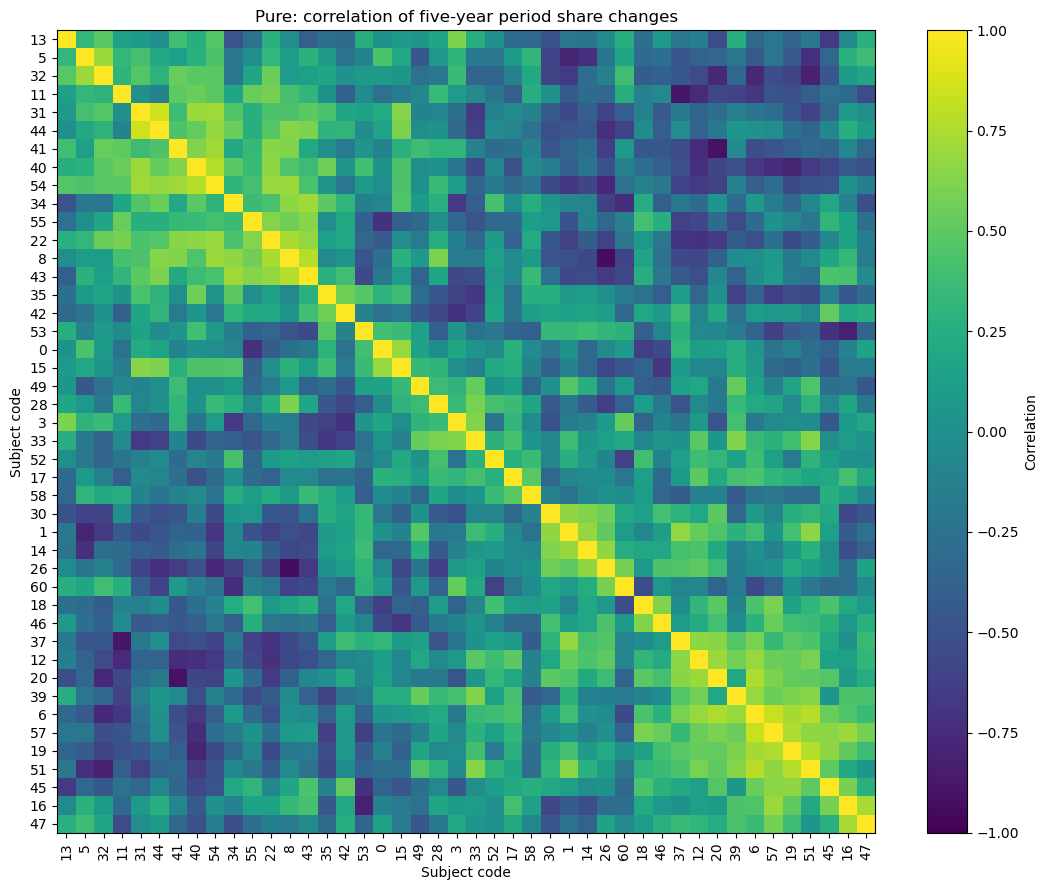

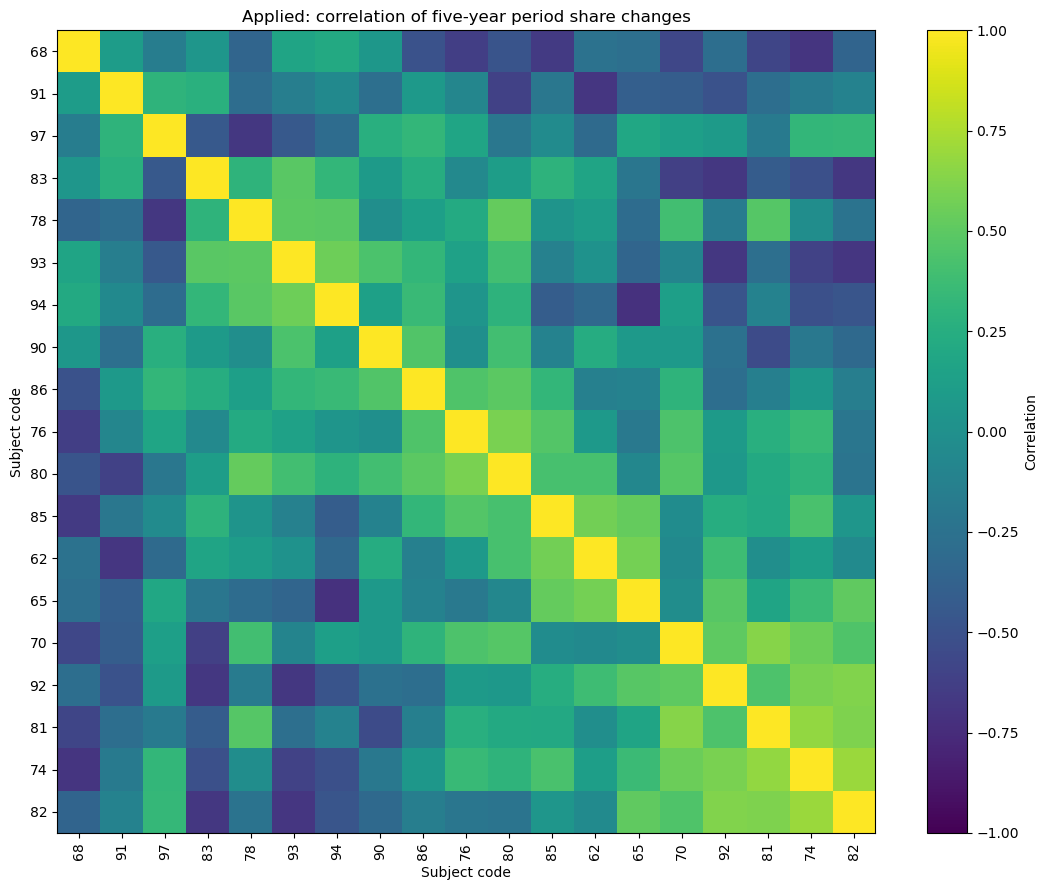

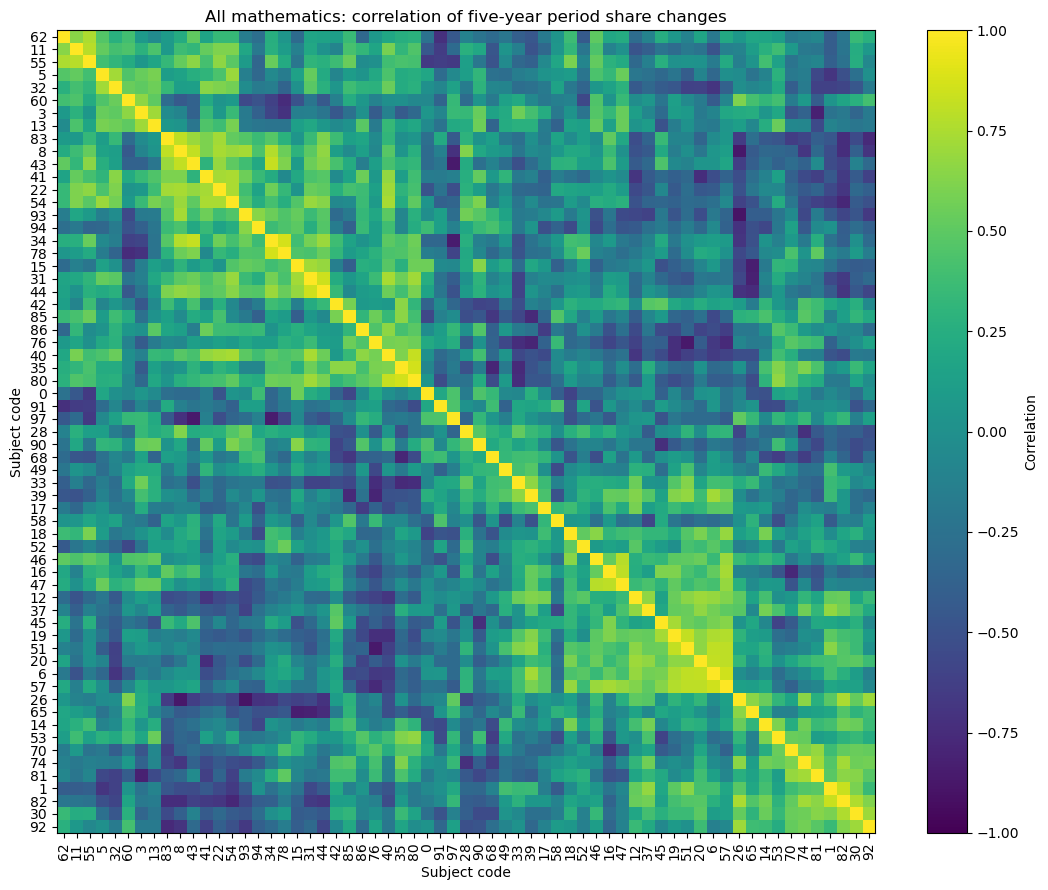

In [18]:
for basket_name, correlation in share_change_correlations.items():
    plot_clustered_correlation(
        correlation,
        title=(
            f"{basket_name}: correlation of "
            "five-year period share changes"
        ),
    )

## 5. Relative co-evolution using log-ratio variation

Share correlations are affected by the constraint

$$
\sum_j p_{j,t}=1.
$$

For subjects $j$ and $k$, consider

$$
\log\frac{p_{j,t}}{p_{k,t}}.
$$

The pairwise log-ratio variation is

$$
V_{jk}
=
\operatorname{Var}_t
\left[
\log\left(
\frac{p_{j,t}}{p_{k,t}}
\right)
\right].
$$

Interpretation:

- small $V_{jk}$: the two subjects maintain a relatively stable ratio and evolve proportionally;
- large $V_{jk}$: their relative importance changes substantially.

A pseudocount of 0.5 is added before taking logarithms so that years with zero observations can be included.

In [19]:
def log_ratio_variation_matrix(
    count_matrix,
    pseudocount=0.5,
):
    adjusted = count_matrix.astype(float) + pseudocount

    composition = adjusted.div(
        adjusted.sum(axis=0),
        axis=1,
    )

    log_composition = np.log(composition)

    subjects = composition.index

    variation = pd.DataFrame(
        np.zeros((len(subjects), len(subjects))),
        index=subjects,
        columns=subjects,
    )

    for left, right in combinations(subjects, 2):
        value = np.var(
            log_composition.loc[left]
            - log_composition.loc[right],
            ddof=1,
        )

        variation.loc[left, right] = value
        variation.loc[right, left] = value

    return variation


def variation_pair_table(variation, top_n=5):
    records = []

    for left, right in combinations(variation.index, 2):
        records.append(
            {
                "subject_1": int(left),
                "name_1": subject_name_map.get(int(left), ""),
                "subject_2": int(right),
                "name_2": subject_name_map.get(int(right), ""),
                "log_ratio_variance": variation.loc[left, right],
            }
        )

    pairs = pd.DataFrame(records)

    proportional = pairs.nsmallest(
        top_n,
        "log_ratio_variance",
    ).assign(relationship="most proportional")

    divergent = pairs.nlargest(
        top_n,
        "log_ratio_variance",
    ).assign(relationship="most divergent")

    return pd.concat(
        [proportional, divergent],
        ignore_index=True,
    )


variation_matrices = {
    name: log_ratio_variation_matrix(
        basket["counts"]
    )
    for name, basket in baskets.items()
}

variation_pairs = pd.concat(
    [
        variation_pair_table(variation).assign(
            distribution=name
        )
        for name, variation
        in variation_matrices.items()
    ],
    ignore_index=True,
)

display(
    variation_pairs[
        [
            "distribution",
            "relationship",
            "subject_1",
            "name_1",
            "subject_2",
            "name_2",
            "log_ratio_variance",
        ]
    ].round(3)
)

,distribution,relationship,subject_1,name_1,subject_2,name_2,log_ratio_variance
0,Pure,most proportional,47,Operator theory,60,Probability theory and stochastic processes,0.093
1,Pure,most proportional,35,Partial differential equations,53,Differential geometry,0.099
2,Pure,most proportional,3,Mathematical logic and foundations,46,Functional analysis,0.106
3,Pure,most proportional,3,Mathematical logic and foundations,60,Probability theory and stochastic processes,0.107
4,Pure,most proportional,34,Ordinary differential equations,46,Functional analysis,0.110
5,Pure,most divergent,5,Combinatorics,40,"Sequences, series, summability",2.413
6,Pure,most divergent,1,History and biography,5,Combinatorics,2.278
7,Pure,most divergent,5,Combinatorics,31,Potential theory,1.944
8,Pure,most divergent,14,Algebraic geometry,40,"Sequences, series, summability",1.888
9,Pure,most divergent,5,Combinatorics,54,General topology,1.853


## 6. Absolute count-growth co-movement

Share changes measure changes in **relative prominence**.

Count changes measure changes in the absolute number of recorded graduates.

For each five-year period, counts are pooled and transformed using

$$
\log(1+\mathrm{count}).
$$

The notebook then correlates changes in these transformed period counts. Positive count-growth correlation can partly reflect common growth in the entire basket, so it should be interpreted together with the share-change and log-ratio analyses.

In [20]:
def period_log_count_changes(count_matrix, width=5):
    pooled_counts = aggregate_period_counts(
        count_matrix,
        width=width,
    )

    log_counts = np.log1p(pooled_counts)

    changes = (
        log_counts
        .diff(axis=1)
        .iloc[:, 1:]
    )

    labels = list(pooled_counts.columns)

    changes.columns = [
        f"{earlier} to {later}"
        for earlier, later
        in zip(labels[:-1], labels[1:])
    ]

    return changes


count_growth_correlations = {
    name: subject_correlation(
        period_log_count_changes(
            basket["counts"],
            width=5,
        )
    )
    for name, basket in baskets.items()
}

count_growth_pairs = pd.concat(
    [
        correlation_pair_table(correlation).assign(
            distribution=name
        )
        for name, correlation
        in count_growth_correlations.items()
    ],
    ignore_index=True,
)

display(
    count_growth_pairs[
        [
            "distribution",
            "direction",
            "subject_1",
            "name_1",
            "subject_2",
            "name_2",
            "correlation",
        ]
    ].round(3)
)

,distribution,direction,subject_1,name_1,subject_2,name_2,correlation
0,Pure,positive,46,Functional analysis,47,Operator theory,0.956
1,Pure,positive,34,Ordinary differential equations,43,Abstract harmonic analysis,0.926
2,Pure,positive,16,Associative rings and algebras,47,Operator theory,0.911
3,Pure,positive,5,Combinatorics,16,Associative rings and algebras,0.898
4,Pure,positive,5,Combinatorics,32,Several complex variables and analytic spaces,0.881
5,Pure,negative,8,General algebraic systems,26,Real functions,-0.477
6,Pure,negative,26,Real functions,44,"Integral transforms, operational calculus",-0.412
7,Pure,negative,26,Real functions,41,Approximations and expansions,-0.393
8,Pure,negative,15,Linear and multilinear algebra; matrix theory,26,Real functions,-0.279
9,Pure,negative,14,Algebraic geometry,44,"Integral transforms, operational calculus",-0.253


## 7. Interpretation guide

Use the analyses together rather than treating any one statistic as definitive.

### Historical composition

- The area plots summarize which subjects dominate each distribution and how that composition changes.
- The all-math distribution combines changes within the pure and applied baskets with changes in the relative sizes of those baskets.

### Diversity

- Rising normalized entropy indicates a more even distribution across subjects.
- Falling normalized entropy indicates increasing concentration.
- The effective number translates entropy into the equivalent number of equally represented subjects.

### Distributional shifts

- Peaks in consecutive-period JSD identify intervals with the greatest overall compositional change.
- Decade JSD heatmaps show which historical eras have similar or different subject distributions.

### Co-evolution

- Positive share-change correlation means that two subjects tend to gain or lose share during the same five-year transitions.
- Negative share-change correlation can partly arise from the constant-sum constraint.
- Small log-ratio variation gives stronger evidence that two subjects maintain a stable relative balance.

### Relative versus absolute growth

- Share-change co-movement concerns relative prominence.
- Count-growth co-movement concerns absolute numbers of recorded graduates.
- Subjects can grow together in counts without maintaining the same relative shares.

These analyses are descriptive and exploratory. Correlation and co-movement should not be interpreted as causation.